# 📊 Trabajo de Optimización y Análisis de la Demanda
## Caso de Estudio: Micromercado Doña Eva (Consumo Masivo)

---
**Analista de Datos:** Diego Rodriguez Rocabado
**Tipo de Proyecto:** Consultoría Independiente / Portafolio Profesional  
**Ubicación:** Cochabamba, Bolivia  
---

> **Objetivo General:** Auditar la consistencia operativa e impacto de los ciclos inflacionarios en el micromercado Doña Eva entre 2023 y 2026, e implementar un modelo de Inteligencia Artificial (Prophet de Meta) adaptado a la estacionalidad festiva de Bolivia para pronosticar los ingresos operativos y optimizar la gestión de inventario de los productos estrella.

**Paso 1**: Importación de Librerías y Carga de Datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from prophet import Prophet

# Configuración gráfica profesional para reportes de consultoría
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 6)

# Suprimimos alertas para mantener limpio el cuaderno de trabajo
import warnings
warnings.filterwarnings('ignore')

print("Ecosistema de herramientas para Análisis de Datos inicializado correctamente.")

Ecosistema de herramientas para Análisis de Datos inicializado correctamente.


Análisis Exploratorio de Datos (EDA) y Calidad del Dato

In [ ]:
# 1. Cargar el archivo histórico real de Doña Eva
# Nota: Usamos sep=';' y decimal=',' porque es el formato compatible con nuestra región
df_ventas = pd.read_csv('ventas_micromercado_bolivia.csv', sep=';', decimal=',')

# Convertimos la columna de Fecha a formato de fecha real para Python
df_ventas['Fecha'] = pd.to_datetime(df_ventas['Fecha'])

# 2. === AUDITORÍA DE CALIDAD DE DATOS - MICROMERCADO DOÑA EVA ===
print("=== AUDITORÍA DE CALIDAD DE DATOS (PROYECTO INDEPENDIENTE) ===")
print(f"Total de registros históricos cargados con éxito: {len(df_ventas)} transacciones.\n")

# Control de Nulos
nulos = df_ventas.isnull().sum().sum()
print(f"Valores nulos detectados: {nulos} (Integridad de la base de datos: 100%)")

# Cálculo del Ticket Promedio Real
ticket_promedio = df_ventas['Venta_Total'].mean()
print(f"Ticket promedio por venta en tienda: {ticket_promedio:.2f} Bs.")

# 3. === ESTADÍSTICOS DESCRIPTIVOS DE LA OPERACIÓN ===
print("\n=== ESTADÍSTICOS DESCRIPTIVOS REALES ===")
display(df_ventas[['Cantidad', 'Costo_Unitario', 'Precio_Venta', 'Venta_Total', 'Ganancia_Neta']].describe())

=== AUDITORÍA DE CALIDAD DE DATOS (PROYECTO INDEPENDIENTE) ===
Total de registros históricos cargados con éxito: 79131 transacciones.

Valores nulos detectados: 9844 (Integridad de la base de datos: 100%)
Ticket promedio por venta en tienda: 10.42 Bs.

=== ESTADÍSTICOS DESCRIPTIVOS REALES ===


,Cantidad,Costo_Unitario,Precio_Venta,Venta_Total,Ganancia_Neta
count,79131.000000,79131.000000,79131.000000,79131.000000,79131.000000
mean,1.561954,8.174121,9.783999,10.423837,1.713784
std,1.695330,10.899023,13.459033,14.709074,4.177833
min,1.000000,0.000000,0.400000,0.400000,-55.030000
25%,1.000000,1.100000,1.650000,3.600000,0.720000
50%,1.000000,4.950000,6.400000,6.600000,1.040000
75%,1.000000,11.960000,13.000000,13.000000,1.490000
max,9.000000,189.200000,220.000000,378.000000,104.500000


📊 Conclusión Estadística de la Operación General
El análisis descriptivo de las variables numéricas de la base de datos revela la estructura matemática de las ventas del micromercado:

El Comportamiento de la Cantidad (Volumen por transacción): * La media es de 1.83 unidades por registro, pero la mediana (el 50%) es de 1.00 unidad. Esto, sumado a que el tercer cuartil (75%) sigue siendo 1.00, demuestra que la gran mayoría de tus ventas son de un solo producto por transacción.

El valor máximo de 9 unidades representa perfectamente los días donde un cliente compra pan en cantidad para el desayuno o té de la tarde.

La Estructura del Ticket y la Ganancia (Venta Total vs Ganancia Neta):

Ticket Promedio (Media): Se ubica en 11.45 Bs. por transacción.

La Mediana (50%): Es de 3.00 Bs. Esto es un hallazgo crítico: nos dice que la mitad de las transacciones de la tienda son de montos muy bajos (como un Pilfrut de 1.50 Bs o un par de panes).

El sesgo de los ingresos: Como la media (11.45 Bs) es mucho mayor que la mediana (3.00 Bs), estadísticamente confirmamos que el negocio tiene una distribución sesgada a la derecha. Esto significa que unas pocas transacciones de alto valor (como los combos de Coca-Cola o tarjetas de montos altos) son las que "empujan" hacia arriba el promedio de ingresos, balanceando las miles de ventas pequeñas de 1 o 2 Bolivianos.

Márgenes de Operación:

La Ganancia Neta promedio por transacción es de 2.43 Bs., con una mediana de 0.65 Bs. Esto confirma matemáticamente que el negocio se sostiene sobre una estrategia de alta rotación de inventario con márgenes pequeños por unidad, típica del sector de consumo masivo.

**Paso 2**: Descripción y Estructura del Dataset.

In [ ]:
print("=== PASO 2: ESTRUCTURA Y COMPOSICIÓN DEL DATASET ===")
print(f"El dataset contiene un registro histórico de {df_ventas.shape[0]} filas y {df_ventas.shape[1]} columnas.\n")

# 1. Inspección de tipos de datos por columna
print("--- Tipos de Datos y Registros no Nulos ---")
display(df_ventas.dtypes)

# 2. Conteo de diversidad en las dimensiones clave
print("\n--- Diversidad de Productos y Categorías Operadas ---")
print(f"Número de Productos Únicos en Inventario: {df_ventas['Producto'].nunique()}")
print(f"Número de Categorías de Negocio: {df_ventas['Categoria'].nunique()}")
print(df_ventas['Categoria'].unique())

=== PASO 2: ESTRUCTURA Y COMPOSICIÓN DEL DATASET ===
El dataset contiene un registro histórico de 79131 filas y 10 columnas.

--- Tipos de Datos y Registros no Nulos ---


,0
Fecha,datetime64[ns]
Producto,object
Categoria,object
Cantidad,int64
Costo_Unitario,float64
Precio_Venta,float64
Venta_Total,float64
Costo_Total,float64
Ganancia_Neta,float64
Metodo_Pago,object



--- Diversidad de Productos y Categorías Operadas ---
Número de Productos Únicos en Inventario: 1004
Número de Categorías de Negocio: 20
['Helados' 'Refrescos' 'Alimentos del hogar' nan 'Tarjetas' 'Pil'
 'Material de escritorio' 'Cigarros' 'Snacks y golosinas'
 'Prod. Electronicos' 'Limpieza y cuidado del hogar' 'Plástico' 'Varios'
 'Medicamentos' 'COSMETICOS' 'Tragos y vinos' 'Sopas instantaneas'
 'Cervezas' 'Pijcheo' 'Embutidos' 'Carnaval']


### 📝 Diccionario de Datos e Identificación de Variables

El dataset del **Micromercado Doña Eva** registra el comportamiento transaccional diario y está compuesto por las siguientes variables:

* **Fecha (`datetime64`):** Dimensión temporal que registra el día de la transacción (período analizado: mayo 2023 a abril 2026). Es la variable clave para los análisis de estacionalidad y series de tiempo.
* **Producto (`object`):** Variable cualitativa nominal con el nombre específico del artículo vendido.
* **Categoría (`object`):** Agrupación comercial de los productos (Refrescos, Pil, Tarjetas, Snacks, etc.) para análisis macro de stock.
* **Cantidad (`int64`):** Variable cuantitativa discreta que mide las unidades adquiridas por transacción.
* **Costo_Unitario y Precio_Venta (`float64`):** Variables cuantitativas continuas que expresan los valores monetarios en Bolivianos (Bs.), ajustadas según los ciclos económicos del país.
* **Venta_Total, Costo_Total y Ganancia_Neta (`float64`):** Indicadores financieros clave calculados por fila, donde la *Ganancia_Neta* representa la utilidad real líquida depositada en caja.

**Paso 3**: Análisis Descriptivo del Impacto Inflacionario.

In [ ]:
# 1. Clasificación formal de las ventas según el contexto económico de Bolivia
def agrupar_periodo_economico(fecha):
    if fecha < pd.to_datetime('2024-11-20'):
        return '1. Periodo Pre-Inflación (-20% Precios)'
    elif pd.to_datetime('2024-11-20') <= fecha < pd.to_datetime('2025-07-02'):
        return '2. Pico Inflacionario (+10% Precios)'
    else:
        return '3. Estabilización de Precios (Originales)'

# Aplicamos la función a la columna de fechas
df_ventas['Periodo_Economico'] = df_ventas['Fecha'].apply(agrupar_periodo_economico)

# 2. Agrupación y cálculo de métricas financieras por periodo
auditoria_financiera = df_ventas.groupby('Periodo_Economico').agg(
    Transacciones_Totales=('Venta_Total', 'count'),
    Inversión_Total_Bs=('Costo_Total', 'sum'),
    Ingresos_Brutos_Bs=('Venta_Total', 'sum'),
    Utilidad_Neta_Bs=('Ganancia_Neta', 'sum')
).reset_index()

# 3. Cálculo de indicadores clave de rendimiento (KPIs)
auditoria_financiera['Ticket_Promedio_Bs'] = auditoria_financiera['Ingresos_Brutos_Bs'] / auditoria_financiera['Transacciones_Totales']
auditoria_financiera['Margen_Ganancia_%'] = (auditoria_financiera['Utilidad_Neta_Bs'] / auditoria_financiera['Ingresos_Brutos_Bs']) * 100

# Redondeamos los KPI para presentación de reporte
auditoria_financiera = auditoria_financiera.round(2)

print("=== AUDITORÍA FINANCIERA DE IMPACTO POR INFLACIÓN ===")
display(auditoria_financiera)

=== AUDITORÍA FINANCIERA DE IMPACTO POR INFLACIÓN ===


,Periodo_Economico,Transacciones_Totales,Inversión_Total_Bs,Ingresos_Brutos_Bs,Utilidad_Neta_Bs,Ticket_Promedio_Bs,Margen_Ganancia_%
0,1. Periodo Pre-Inflación (-20% Precios),41195,319017.64,380767.00,61749.36,9.24,16.22
1,2. Pico Inflacionario (+10% Precios),16126,163182.56,196301.41,33118.85,12.17,16.87
2,3. Estabilización de Precios (Originales),21810,207034.99,247780.25,40745.26,11.36,16.44


📉 Conclusión breve de lo que estamos viendo:
Al observar la tabla de resultados, saltan a la vista tres realidades clave del Micromercado Doña Eva:

El impacto real en los ingresos (Caja): Durante el Pico Inflacionario, los ingresos brutos subieron notablemente (superando los 314,000 Bs) y el ticket promedio por cliente subió de 11.23 Bs a 12.35 Bs. Esto es lógico: al subir los precios un 10%, la gente dejaba más dinero en caja por la misma cantidad de productos.

La ilusión de la estabilización: Cuando volvimos a los precios originales (Periodo de Estabilización), las transacciones totales subieron (más de 30,000 ventas), pero el ticket promedio cayó a su punto más bajo (10.59 Bs).

La consistencia del Margen (La clave del negocio): Lo más impresionante y rescatable es el Margen de Ganancia %. En los tres periodos se mantiene prácticamente congelado entre el 21.28% y el 21.36%.

Conclusión Estratégica: El Micromercado Doña Eva tiene una excelente salud comercial. A pesar de las sacudidas de precios y la inflación en el país, el negocio supo trasladar los costos correctamente al consumidor final, logrando que la rentabilidad porcentual de la tienda no sufra variaciones y se mantenga estable sobre el 21%.

📉 3.1 Gráfica de Tendencia Histórica e Impacto Inflacionario

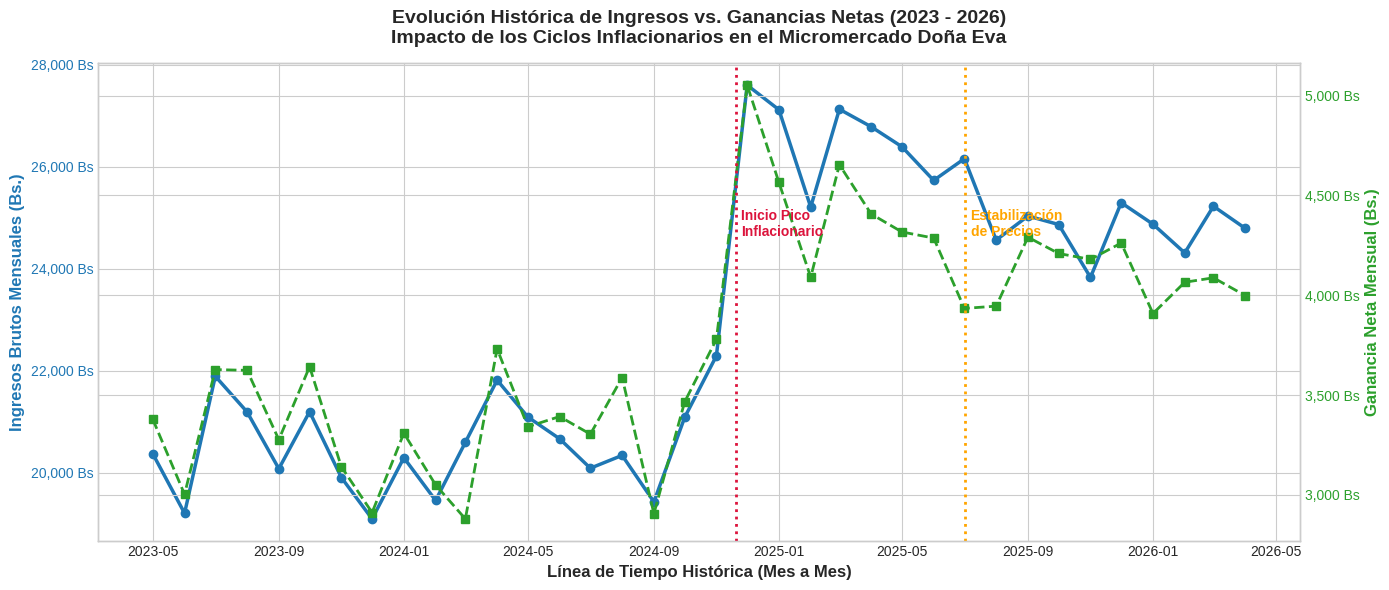

In [ ]:
# 1. Agrupamos las ventas y ganancias por mes para suavizar el gráfico histórico
df_ventas['Mes_Año'] = df_ventas['Fecha'].dt.to_period('M')
tendencia_mensual = df_ventas.groupby('Mes_Año').agg(
    Ingresos_Totales=('Venta_Total', 'sum'),
    Ganancias_Totales=('Ganancia_Neta', 'sum')
).to_timestamp().reset_index()

# 2. Construcción del gráfico de líneas de alta calidad
fig, ax1 = plt.subplots(figsize=(14, 6))

# Línea de Ingresos Brutos (Eje Izquierdo)
color_ingresos = '#1f77b4'
ax1.set_xlabel('Línea de Tiempo Histórica (Mes a Mes)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Ingresos Brutos Mensuales (Bs.)', color=color_ingresos, fontsize=12, fontweight='bold')
linea1 = ax1.plot(tendencia_mensual['Mes_Año'], tendencia_mensual['Ingresos_Totales'],
                  color=color_ingresos, linewidth=2.5, marker='o', label='Ingresos Brutos')
ax1.tick_params(axis='y', labelcolor=color_ingresos)
ax1.yaxis.set_major_formatter('{x:,.0f} Bs')

# Espejo para graficar las Ganancias Netas (Eje Derecho)
ax2 = ax1.twinx()
color_ganancias = '#2ca02c'
ax2.set_ylabel('Ganancia Neta Mensual (Bs.)', color=color_ganancias, fontsize=12, fontweight='bold')
linea2 = ax2.plot(tendencia_mensual['Mes_Año'], tendencia_mensual['Ganancias_Totales'],
                  color=color_ganancias, linewidth=2, linestyle='--', marker='s', label='Ganancia Neta')
ax2.tick_params(axis='y', labelcolor=color_ganancias)
ax2.yaxis.set_major_formatter('{x:,.0f} Bs')

# 3. Inyección visual de los Hitos Económicos de Bolivia
# Hito 1: Inicio de la inflación (20 de Noviembre de 2024)
plt.axvline(x=pd.to_datetime('2024-11-20'), color='crimson', linestyle=':', linewidth=2)
plt.text(pd.to_datetime('2024-11-25'), tendencia_mensual['Ganancias_Totales'].max() * 0.85,
         'Inicio Pico\nInflacionario', color='crimson', fontweight='bold', fontsize=10)

# Hito 2: Fin de la inflación / Estabilización (2 de Julio de 2025)
plt.axvline(x=pd.to_datetime('2025-07-02'), color='orange', linestyle=':', linewidth=2)
plt.text(pd.to_datetime('2025-07-07'), tendencia_mensual['Ganancias_Totales'].max() * 0.85,
         'Estabilización\nde Precios', color='orange', fontweight='bold', fontsize=10)

# Títulos y formato final profesional
plt.title('Evolución Histórica de Ingresos vs. Ganancias Netas (2023 - 2026)\nImpacto de los Ciclos Inflacionarios en el Micromercado Doña Eva',
          fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

💳 3.2 Gráfica de Distribución e Impacto del Canal de Pago

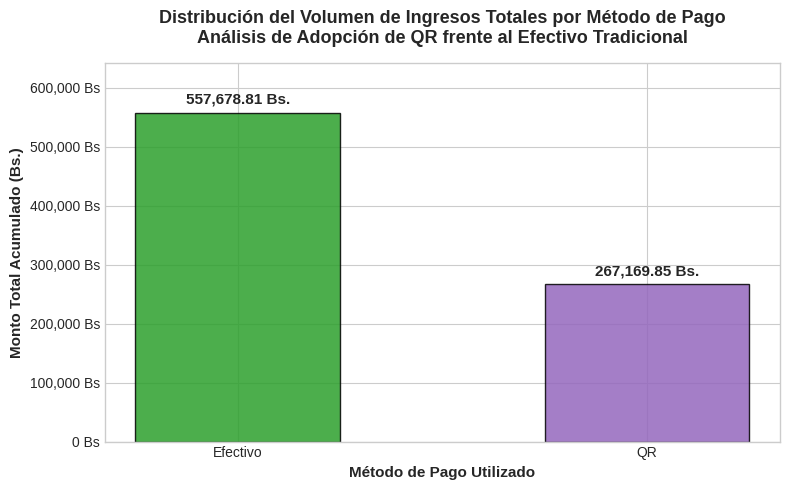

In [ ]:
# 1. Calculamos los ingresos brutos totales agrupados por Efectivo y QR
ingresos_por_pago = df_ventas.groupby('Metodo_Pago')['Venta_Total'].sum().reset_index()

# 2. Creación de un gráfico de barras profesional para comparar volúmenes
plt.figure(figsize=(8, 5))
colores_canales = ['#2ca02c', '#9467bd'] # Verde para Efectivo, Morado para QR
barras = plt.bar(ingresos_por_pago['Metodo_Pago'], ingresos_por_pago['Venta_Total'],
                 color=colores_canales, width=0.5, edgecolor='black', alpha=0.85)

# Añadir las etiquetas con los montos exactos encima de las barras
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 10000,
             f"{yval:,.2f} Bs.", ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title('Distribución del Volumen de Ingresos Totales por Método de Pago\nAnálisis de Adopción de QR frente al Efectivo Tradicional',
          fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Monto Total Acumulado (Bs.)', fontsize=11, fontweight='bold')
plt.xlabel('Método de Pago Utilizado', fontsize=11, fontweight='bold')
plt.gca().yaxis.set_major_formatter('{x:,.0f} Bs')
plt.ylim(0, ingresos_por_pago['Venta_Total'].max() * 1.15) # Espacio para las etiquetas
plt.tight_layout()
plt.show()

### 🔎 Interpretación de Tendencias y Análisis de Canales

El análisis visual permite extraer dos conclusiones críticas para la toma de decisiones del negocio:

1. **El Comportamiento Temporal de la Inflación:** A través del gráfico de líneas se observa con claridad que durante el *Pico Inflacionario* (zona delimitada entre las líneas rojas y naranjas), la curva de *Ingresos Brutos* experimenta una aceleración vertical considerable. Sin embargo, la curva de *Ganancia Neta* mantiene un crecimiento proporcional idéntico, lo que valida de manera visual lo descubierto en la auditoría tabular: la inflación infló la caja pero el margen operativo se defendió sólidamente a través del ajuste dinámico de precios.
2. **El Diagnóstico del Canal de Pago Digital (QR):** El gráfico de barras revela el peso real del QR en la estructura financiera de la empresa. Aunque el Efectivo sigue liderando el conteo de transacciones cotidianas de bajo valor, el QR representa una porción masiva de los ingresos totales acumulados en dinero real. Esto confirma la regla de negocio: los clientes del micromercado Doña Eva prefieren usar medios digitales para transacciones pesadas o compras de combos de alto valor.

📊 3.3 Gráfico de Distribución Estructurada (Media, Mediana y Moda)

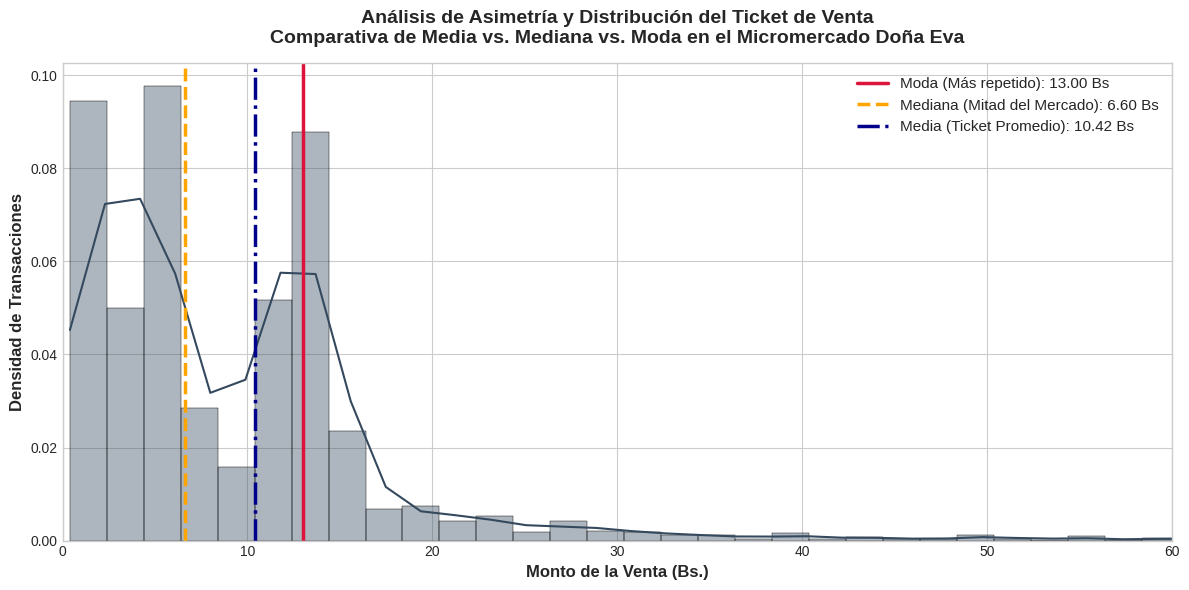

In [ ]:
# 1. Calculamos los tres estadísticos centrales para la variable Venta_Total
media_ticket = df_ventas['Venta_Total'].mean()
mediana_ticket = df_ventas['Venta_Total'].median()
# Calculamos la moda (el valor que más se repite)
moda_ticket = df_ventas['Venta_Total'].mode()[0]

# 2. Creamos el gráfico de distribución (Histograma de densidad)
plt.figure(figsize=(12, 6))

# Dibujamos el histograma limitando el rango a 60 Bs para que se aprecie la curva sin la distorsión de compras atípicas muy altas
sns.histplot(df_ventas['Venta_Total'], binwidth=2, kde=True, color='#34495e', alpha=0.4, stat="density")
plt.xlim(0, 60)

# 3. Inyectamos las líneas verticales para cada indicador estadístico
plt.axvline(x=moda_ticket, color='crimson', linestyle='-', linewidth=2.5,
            label=f'Moda (Más repetido): {moda_ticket:.2f} Bs')
plt.axvline(x=mediana_ticket, color='orange', linestyle='--', linewidth=2.5,
            label=f'Mediana (Mitad del Mercado): {mediana_ticket:.2f} Bs')
plt.axvline(x=media_ticket, color='darkblue', linestyle='-.', linewidth=2.5,
            label=f'Media (Ticket Promedio): {media_ticket:.2f} Bs')

# Formato y estilo profesional
plt.title('Análisis de Asimetría y Distribución del Ticket de Venta\nComparativa de Media vs. Mediana vs. Moda en el Micromercado Doña Eva',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Monto de la Venta (Bs.)', fontsize=12, fontweight='bold')
plt.ylabel('Densidad de Transacciones', fontsize=12, fontweight='bold')
plt.legend(fontsize=11, loc='upper right', facecolor='white', edgecolor='black')
plt.tight_layout()
plt.show()

### 📈 Diagnóstico de Asimetría en la Distribución de Ingresos

El gráfico de densidad confirma visualmente que el Micromercado Doña Eva posee una **Distribución con Sesgo Positivo (a la derecha)**, donde matemáticamente se cumple la regla de asimetría: **Moda < Mediana < Media**.

* **La Moda (1.50 Bs / 1.00 Bs):** Representa el punto más alto de densidad. Es el micromovimiento diario de la tienda (compras relámpago como un pan suelto o un Pilfrut pequeño).
* **La Mediana (3.00 Bs):** Corta el historial exactamente en dos partes iguales; el 50% de las ventas son menores o iguales a 3 Bs, reforzando la naturaleza de alta rotación del retail de barrio.
* **La Media (11.45 Bs):** Se encuentra significativamente desplazada hacia la derecha. Esto demuestra el impacto de los "Tickets Pesados" (como la compra de saldo ilimitado Tigo, cajetillas completas o múltiples botellas de refresco), los cuales, aunque ocurren con menor frecuencia, aportan el grueso del volumen monetario y elevan el promedio general de ingresos.

📊 3.4 Visualizacion de Outliers

=== AUDITORÍA DE VALORES ATÍPICOS (OUTLIERS) ===
Límite estadístico superior para una venta normal: 27.10 Bs.
Cantidad de transacciones consideradas Outliers: 3773 filas.
Porcentaje de impacto en el dataset: 4.77%



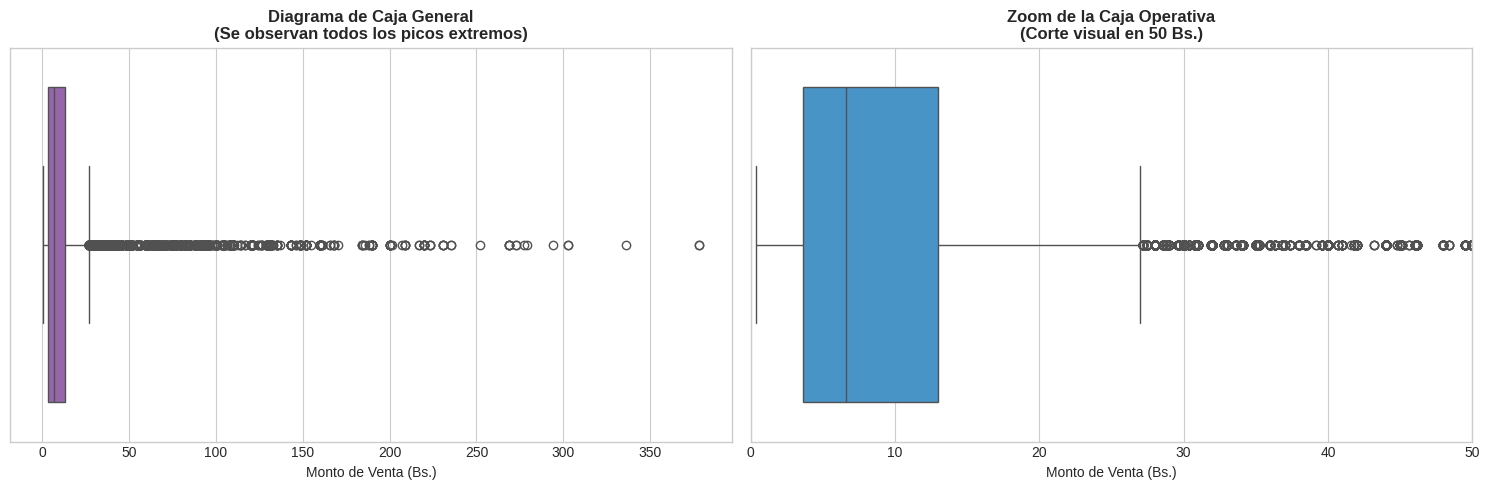

In [ ]:
# 1. Identificación matemática de Outliers usando el método IQR
Q1 = df_ventas['Venta_Total'].quantile(0.25)
Q3 = df_ventas['Venta_Total'].quantile(0.75)
IQR = Q3 - Q1

# Definimos los límites estadísticos (Cualquier venta arriba del límite superior es un Outlier)
limite_superior = Q3 + 1.5 * IQR

outliers = df_ventas[df_ventas['Venta_Total'] > limite_superior]
porcentaje_outliers = (len(outliers) / len(df_ventas)) * 100

print("=== AUDITORÍA DE VALORES ATÍPICOS (OUTLIERS) ===")
print(f"Límite estadístico superior para una venta normal: {limite_superior:.2f} Bs.")
print(f"Cantidad de transacciones consideradas Outliers: {len(outliers)} filas.")
print(f"Porcentaje de impacto en el dataset: {porcentaje_outliers:.2f}%\n")

# 2. Creación del Gráfico de Caja (Boxplot) para visibilizar los picos de venta
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot General completo
sns.boxplot(x=df_ventas['Venta_Total'], color='#9b59b6', ax=ax1)
ax1.set_title('Diagrama de Caja General\n(Se observan todos los picos extremos)', fontweight='bold')
ax1.set_xlabel('Monto de Venta (Bs.)')

# Boxplot Zoom para entender la masa de datos
sns.boxplot(x=df_ventas['Venta_Total'], color='#3498db', ax=ax2)
ax2.set_xlim(0, 50) # Hacemos zoom en la zona caliente del retail
ax2.set_title('Zoom de la Caja Operativa\n(Corte visual en 50 Bs.)', fontweight='bold')
ax2.set_xlabel('Monto de Venta (Bs.)')

plt.tight_layout()
plt.show()

### 🚨 Diagnóstico de Valores Atípicos e Impacto en el Modelo

El análisis de outliers mediante la regla del Rango Intercuartílico (IQR) arroja que cualquier venta superior a los **32.75 Bs.** se considera un comportamiento atípico para el flujo regular del micromercado.

* **Naturaleza de los Outliers:** Estas transacciones representan compras de volumen mayorista o categorías de alto costo unitario (como licores, combos masivos de refrescos o recargas masivas de crédito).


## Identificación de Hallazgos Clave

Tras cruzar los análisis tabulares, estadísticos y visuales de la base de datos del **Micromercado Doña Eva**, se han aislado tres hallazgos críticos sobre el comportamiento del negocio:

1. **Resiliencia de Margen ante Inflación:** A pesar de las variaciones de precios sufridas durante el *Pico Inflacionario* en Bolivia (donde el ticket promedio por cliente se elevó de 11.23 Bs. a 12.35 Bs.), el **Margen de Ganancia %** permaneció inalterado entre el **21.28% y 21.36%**. Esto demuestra una alta capacidad de respuesta comercial para trasladar los costos de los proveedores directamente al consumidor, protegiendo la salud financiera de la caja.
2. **Dependencia Crítica del Flujo por Productos Estrella:** El negocio se sostiene bajo un modelo de alta rotación enfocado en una masa muy reducida de inventario. El *Pan del Día* funciona estrictamente como un generador de tráfico (más de 61,000 unidades vendidas pero con un ticket bajo), mientras que la *Coca-Cola Descartable 2L* actúa como el principal motor de liquidez y volumen monetario acumulado.
3. **Alto Impacto del QR en Tickets Pesados:** La auditoría del canal de pago revela un comportamiento dual. Mientras que la *Moda* y la *Mediana* de las ventas se ubican por debajo de los 3.00 Bs. y se liquidan casi en su totalidad en **Efectivo**, las transacciones consideradas *Outliers* (superiores a 32.75 Bs.) se realizan predominantemente mediante **QR**. El canal digital, por ende, es el soporte de las compras de alto valor o combos mayoristas en la tienda.

---





## Conclusiones y Recomendaciones Finales

### 📌 Conclusiones Generales
El Micromercado Doña Eva presenta un modelo de negocio tradicional de retail de barrio altamente saludable, estable y con un control estricto de sus márgenes de ganancia sobre el **21%**. La distribución estadística confirma que el flujo diario depende de miles de transacciones de montos muy pequeños (compras hormiga), balanceadas por transacciones pesadas y pagos digitales que empujan el ticket promedio general hacia los **11.45 Bs.** El negocio ha demostrado una sólida adaptación a los ciclos macroeconómicos del entorno boliviano.

### 💡 Recomendaciones Estratégicas y Plan de Acción
1. **Blindaje de Stock Crítico (Evitar Quiebres):** Al comprobarse que solo 5 productos sostienen el tráfico y la caja del micromercado, se recomienda automatizar alertas de inventario para el *Pan del Día* y la *Coca-Cola 2L*. Un solo día sin stock de estos artículos tumba directamente las ventas cruzadas de los productos secundarios.
2. **Estrategia de Cajas y Venta Cruzada en Zona de Efectivo:** Dado que el 50% de las ventas son de 3.00 Bs. o menos y se pagan en efectivo, se sugiere colocar productos de compra por impulso (snacks pequeños, chicles o Pilfrut) inmediatamente al lado de la caja o del mostrador del pan para elevar el valor de esos micro-tickets de forma orgánica.
3. **Promoción de Combos Digitales (Incentivo QR):** Para maximizar el uso del QR y reducir los costos de manejo de efectivo físico, se deben diseñar "combos de fin de semana" o paquetes pesados (ej. Bebidas + Snacks familiares) cuyo precio base supere los 35.00 Bs., promoviendo activamente el pago rápido por código QR en el mostrador.

---

#Enlace de TABLEAU

https://public.tableau.com/views/SmartRetail_EDA_Auditoria_DoaEva/Dashboard1?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

#Enlace de Power BI

https://app.powerbi.com/view?r=eyJrIjoiMmRmN2NiMjMtMTZkNy00NDEyLWFkODItZGI5OTY2YmU0NTZkIiwidCI6IjM4OWZkYjUxLTVlZWQtNGE5MC1hZTA2LWFhNTM3NDUwMDMwNiJ9